# Notebook 1: miDGD — TCGA

## Section 1: Library, Functions, and Data Loading

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA


In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebook" else cwd
if not (repo_root / "models").is_dir():
    repo_root = next(
        p for p in (cwd, *cwd.parents)
        if (p / "models").is_dir() and (p / "notebook").is_dir()
    )
for p in (repo_root, repo_root / "notebook"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


In [3]:
%load_ext autoreload
%autoreload 2
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['mathtext.default'] = 'regular'


In [4]:
from base.dgd.nn import NB_Module, ZINB_Module
from base.dgd.DGD import DGD
from base.dgd.latent import RepresentationLayer
from base.utils.helpers import set_seed, get_activation
from base.model.decoder import Decoder
from base.data.combined import GeneExpressionDatasetCombined, StratifiedBatchSampler
from base.plotting.plot import plot_latent_space


In [5]:
from model_functions import load_trained_model, count_parameters, count_parameters_exclude_rep
from data_functions import (
    generate_analysis_data, get_mirna_data as _get_mirna_data,
    _get_data_pred_from_rep, _get_data_pred_from_rep_with_mrna,
)
from plot_functions import (
    barplot_dataset, plot_latent_space_ms, plot_latent_space_dataonly,
    plot_average_correlation, plot_poisson_pseudo_r2_hist, plot_cancer_legend,
    plot_corr_vs_mean_expression_pub, regression_plot, plot_jitter_grouped_tissue,
    mirna_vs_mrna_regression,
)
from metrics_functions import calculate_ari, calculate_corr, poisson_pseudo_r2_vector
from clustering_functions import gmm_clustering, gmm_clustering_plot_diagonal, gmm_clustering_plot_diagonal_new

In [6]:
seed = 42
set_seed(seed)

num_workers = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 128
scaling_type = 'sum'
savedir = str(repo_root / 'plots/1')
os.makedirs(savedir, exist_ok=True)


Device: cpu


In [7]:
df_mrna  = pd.read_table(repo_root / "data" / "TCGA" / "miDGD" / "tcga_mrna.tsv",  sep="\t", index_col=0)
df_mirna = pd.read_table(repo_root / "data" / "TCGA" / "miDGD" / "tcga_mirna.tsv", sep="\t", index_col=0)

anno_train = pd.read_table(repo_root / "data" / "TCGA" / "miDGD" / "TCGA_train_anno.tsv", sep="\t", index_col=0)
anno_val   = pd.read_table(repo_root / "data" / "TCGA" / "miDGD" / "TCGA_val_anno.tsv",   sep="\t", index_col=0)
anno_test  = pd.read_table(repo_root / "data" / "TCGA" / "miDGD" / "TCGA_test_anno.tsv",  sep="\t", index_col=0)

df_anno = pd.concat([anno_train, anno_val, anno_test], axis=0)
print(df_mrna.shape, df_mirna.shape)
print(anno_train.shape, anno_val.shape, anno_test.shape)


(9640, 18393) (9640, 755)
(7230, 6) (1205, 6) (1205, 6)


In [8]:
train_idx = anno_train.index
val_idx   = anno_val.index
test_idx  = anno_test.index

train_mrna = df_mrna.loc[train_idx]
val_mrna   = df_mrna.loc[val_idx]
test_mrna  = df_mrna.loc[test_idx]
train_mirna = df_mirna.loc[train_idx]
val_mirna   = df_mirna.loc[val_idx]
test_mirna  = df_mirna.loc[test_idx]

train_dataset      = GeneExpressionDatasetCombined(train_mrna, train_mirna, anno_train, scaling_type=scaling_type)
validation_dataset = GeneExpressionDatasetCombined(val_mrna,   val_mirna,   anno_val,   scaling_type=scaling_type)
test_dataset       = GeneExpressionDatasetCombined(test_mrna,  test_mirna,  anno_test,  scaling_type=scaling_type)

train_loader      = torch.utils.data.DataLoader(train_dataset,      batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader       = torch.utils.data.DataLoader(test_dataset,       batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

data_loader = train_loader, validation_loader, test_loader

# cancer_type (str_labels) → color: used by latent-space plots
color_mapping = dict(zip(train_loader.dataset.str_labels, train_loader.dataset.color))
# primary_site → color: used by GMM clustering plot
primary_color_mapping = dict(zip(train_loader.dataset.primary_site, train_loader.dataset.color))


## Section 2: Model Loading

In [9]:
dgd = load_trained_model("1-tcga.pth", device)
print(dgd)
print(f"Trainable parameters (excl. representations): {count_parameters_exclude_rep(dgd):,}")


DGD(
  (decoder): Decoder(
    (main): ModuleList(
      (0): Linear(in_features=30, out_features=100, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=100, out_features=100, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=100, out_features=100, bias=True)
      (5): LeakyReLU(negative_slope=0.01)
    )
    (out_module_mirna): ZINB_Module(
      (fc): Sequential(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=256, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=256, out_features=755, bias=True)
      )
    )
    (out_module_mrna): NB_Module(
      (fc): Sequential(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=512, bias=True)
        (3): LeakyReLU(negative

## Section 3: Reproduce Results

### Generate Predictions

In [10]:
from functools import partial

mirna_column = train_mirna.columns
get_mirna_data = partial(
    _get_mirna_data,
    mirna_column_name=mirna_column,
    label_attr="cancer_type",
    include_batch=False,
)

X_train, y_train, X_val, y_val, X_test, y_test = generate_analysis_data(
    dgd, train_loader, validation_loader, test_loader,
    mirna_column_name=mirna_column,
)
X_test.index  = y_test.index  = anno_test.index
X_train.index = y_train.index = anno_train.index


### Figure 2a — Data Distribution

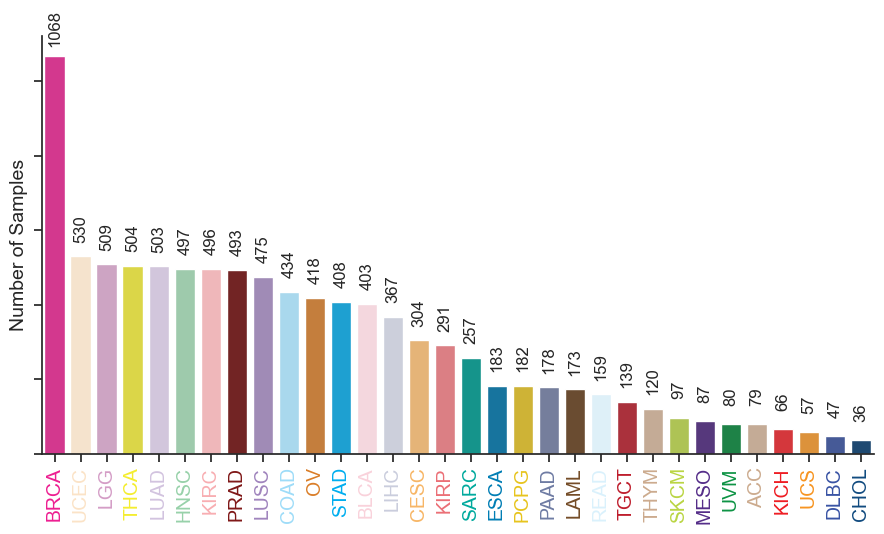

In [11]:
barplot_dataset(
    df_anno, groupby='cancer_type', figsize=(9, 5.5),
    savedir=savedir, filename='Figure 2a - TCGA sample distribution.svg',
    xlabel='', ylabel='Number of Samples',
    xtick_fontsize=14, annotate_fontsize=12, save_format='svg',
)


### Latent Space PCA

Train ARI: 0.3863


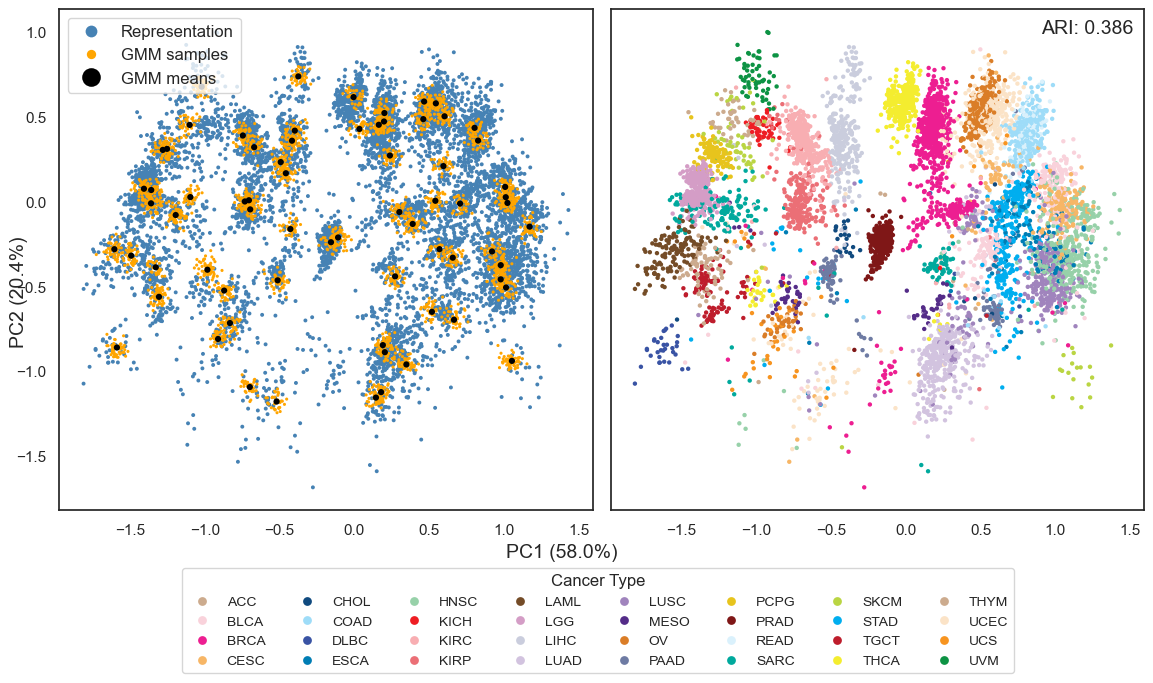

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [12]:
ari = calculate_ari(dgd, dgd.train_rep.z, data_loader, method='gmm', split='train')
print(f"Train ARI: {ari:.4f}")

plot_latent_space_ms(
    *dgd.get_latent_space_values("train", 3000),
    dgd.gmm, train_loader.dataset.str_labels,
    color_mapping, data_loader=train_loader,
    title="Train", savedir=savedir,
    filename="Figure 2bc - TCGA training latent space.svg", ari=ari,
)


Test ARI: 0.4111


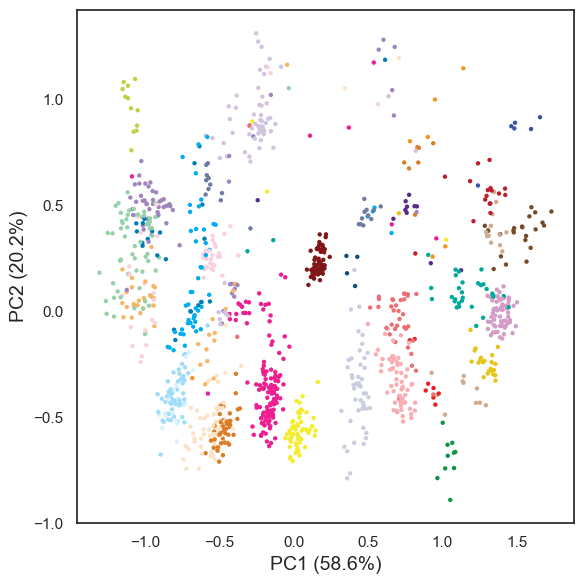

In [13]:
ari_test = calculate_ari(dgd, dgd.test_rep.z, data_loader, method='gmm', split='test')
print(f"Test ARI: {ari_test:.4f}")

plot_latent_space_dataonly(
    *dgd.get_latent_space_values("test", 2000),
    dgd.gmm, test_loader.dataset.str_labels,
    color_mapping, title="Test",
    savedir=savedir, filename="Figure 2d - TCGA test latent space (mRNA only).svg",
)


### Figure 2e — Test Latent Space (miRNA only)

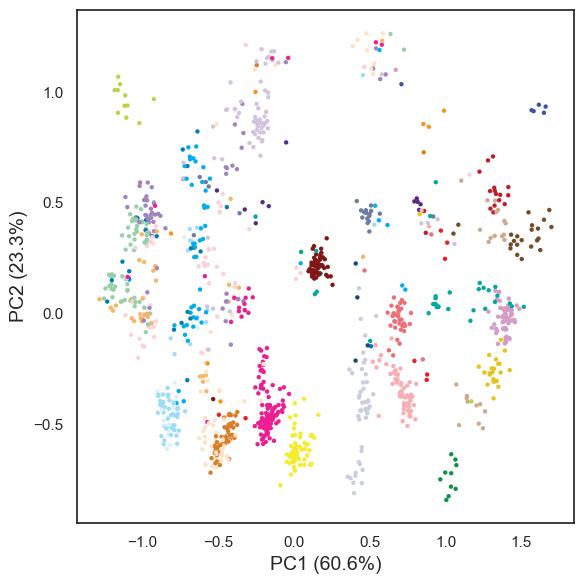

In [14]:
# Figure 2e — test latent space using miRNA-only representations
mirna_rep_z = dgd.test_rep_mirna.z.clone().detach().cpu().numpy()
gmm_means   = dgd.gmm.mean.clone().detach().cpu().numpy()
gmm_samples = dgd.gmm.sample(2000).detach().cpu().numpy()

plot_latent_space_dataonly(
    mirna_rep_z, gmm_means, gmm_samples,
    dgd.gmm, test_loader.dataset.str_labels,
    color_mapping, title="Test (miRNA only)",
    savedir=savedir, filename="Figure 2e - TCGA test latent space (miRNA only).svg",
)


### Supplementary Figure 1ab — TCGA Test Latent Space (GMM structure)

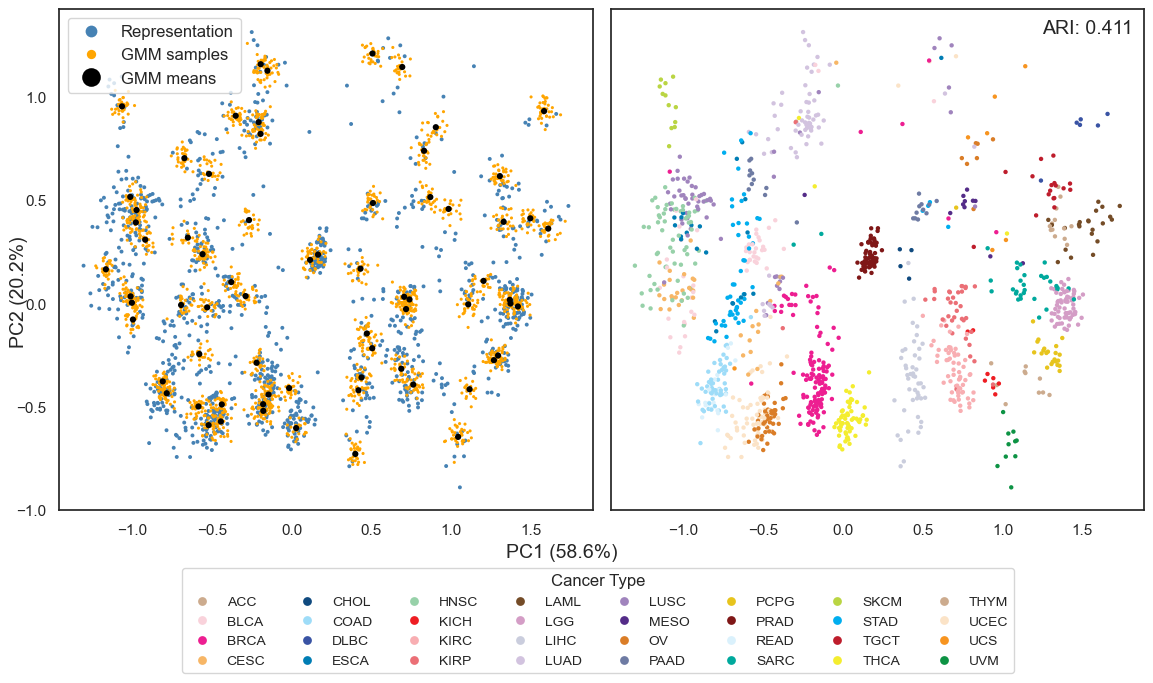

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [15]:
# Supplementary Figure 1ab — TCGA test latent space with GMM structure
plot_latent_space_ms(
    dgd.test_rep.z.clone().detach().cpu().numpy(),
    dgd.gmm.mean.clone().detach().cpu().numpy(),
    dgd.gmm.sample(2000).detach().cpu().numpy(),
    dgd.gmm, test_loader.dataset.str_labels,
    color_mapping, data_loader=None,
    title="Test", savedir=savedir,
    filename="Supplementary Figure 1ab - TCGA test latent space.svg", ari=ari_test,
)


### Supplementary Figure 1cd — GTEx Test Set Under TCGA Model

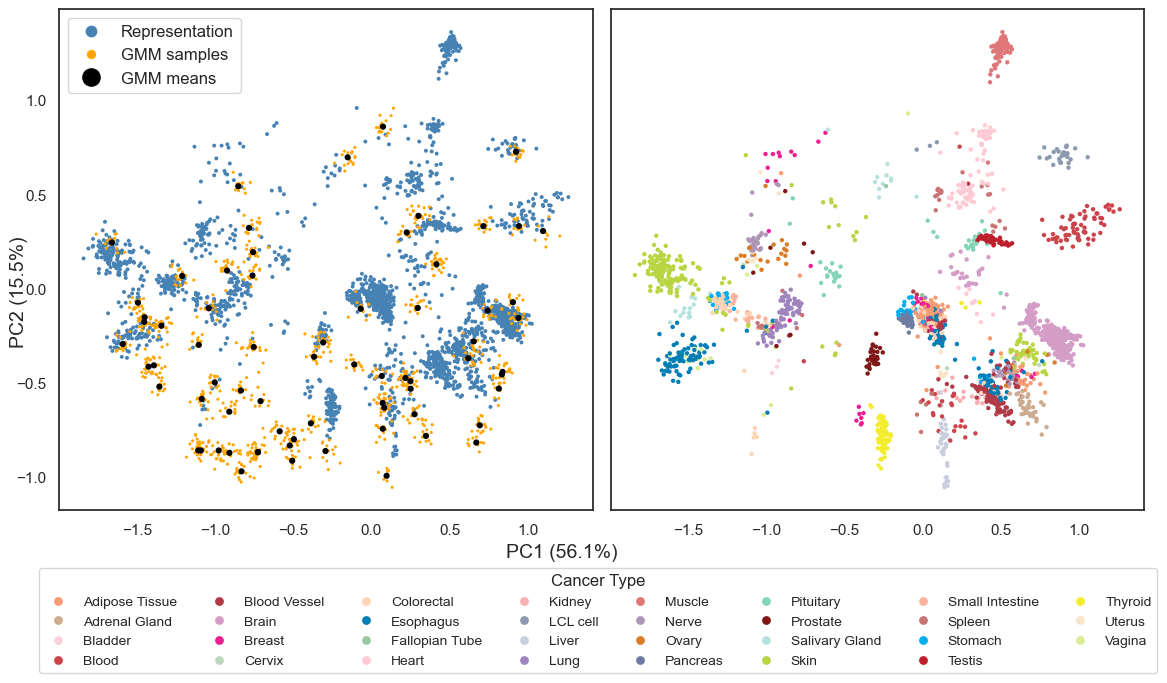

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [16]:
# Supplementary Figure 1cd — GTEx test set representation under TCGA-trained model
from data_functions import replace_tissue_anno

gtex_test_anno = pd.read_table(
    repo_root / "data" / "GTEx" / "miDGD" / "GTEx_test_anno.tsv", sep="\t", index_col=0)
gtex_test_anno["batch"] = "GTEx"
gtex_test_anno = replace_tissue_anno(gtex_test_anno)

gtex_rep_z     = dgd.gtex_rep.z.clone().detach().cpu().numpy()
gtex_labels    = gtex_test_anno["cancer_type"].values
gtex_color_map = dict(zip(gtex_test_anno["cancer_type"], gtex_test_anno["color"]))

plot_latent_space_ms(
    gtex_rep_z,
    dgd.gmm.mean.clone().detach().cpu().numpy(),
    dgd.gmm.sample(1000).detach().cpu().numpy(),
    dgd.gmm, gtex_labels, gtex_color_map,
    data_loader=None, title="GTEx under TCGA model",
    savedir=savedir,
    filename="Supplementary Figure 1cd - GTEx test latent space (TCGA model).svg",
)


### GMM Clustering

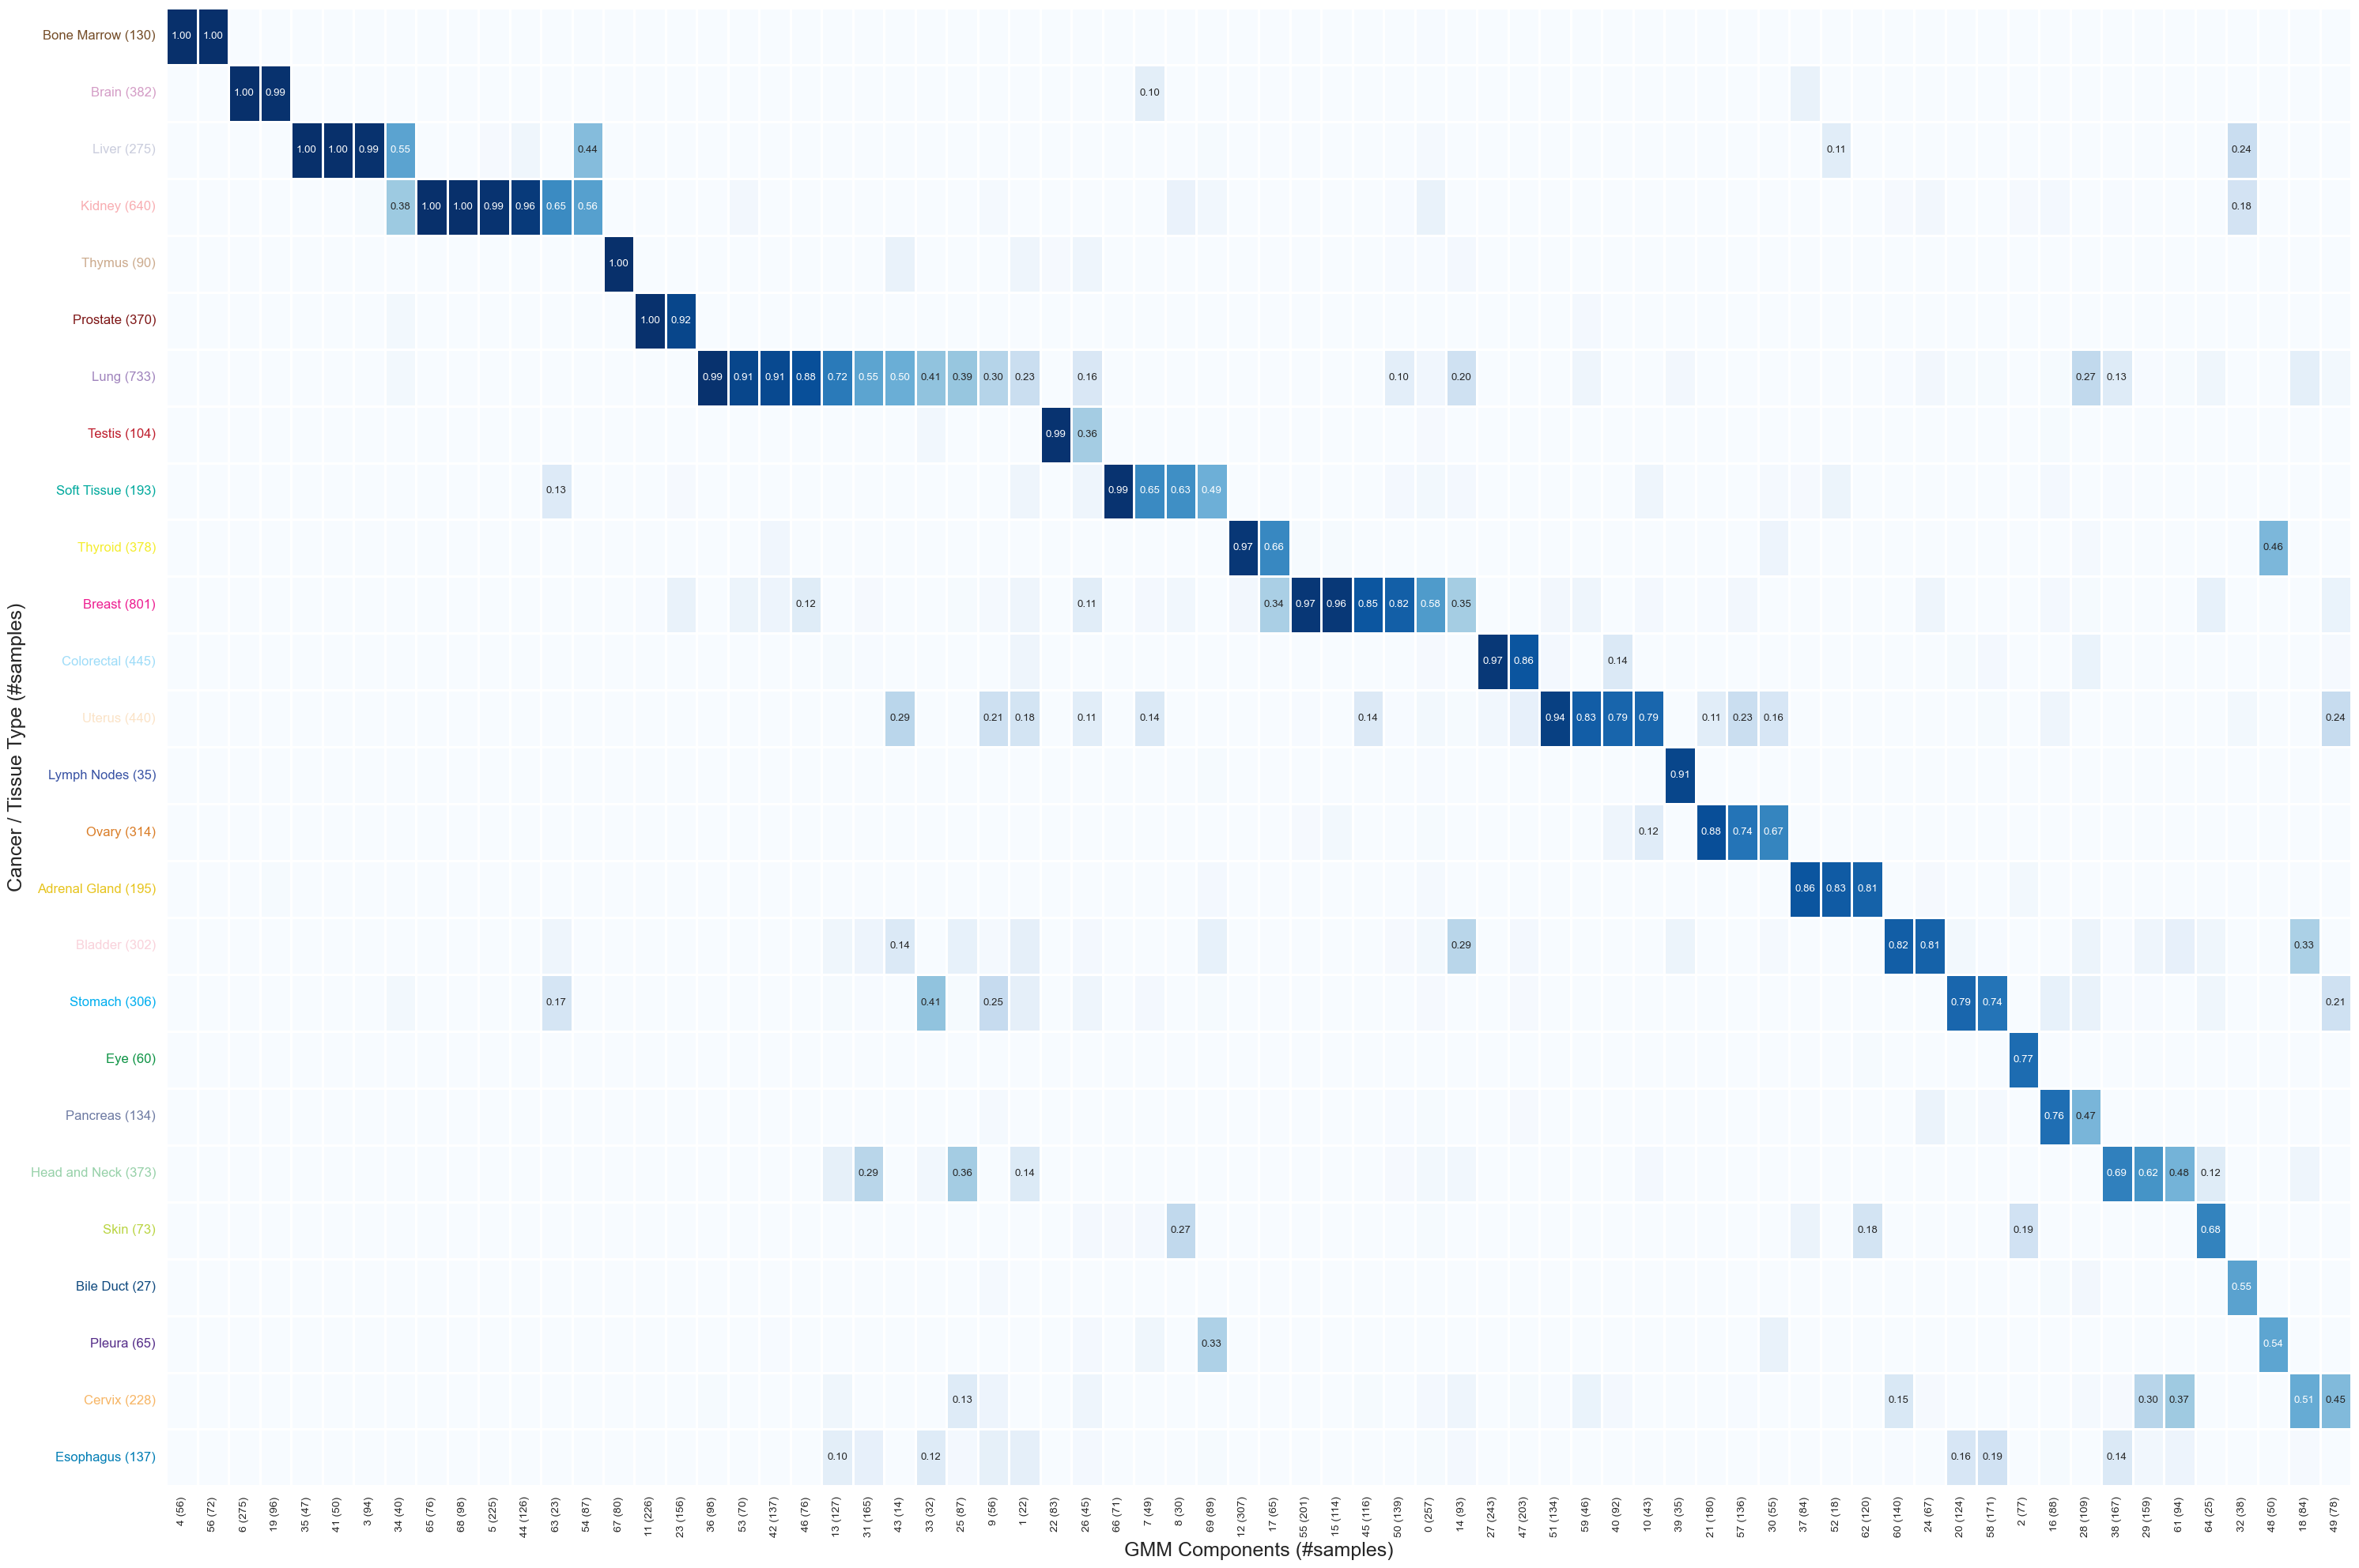

In [17]:
train_clustering = gmm_clustering(dgd, dgd.train_rep)
gmm_clustering_plot_diagonal_new(
    train_clustering, train_loader, primary_color_mapping,
    axis='comp', savedir=savedir, filename='Figure 2f - TCGA GMM component assignment.svg',
)

### Average Correlation

Mean Pearson: 0.5730  Mean Spearman: 0.5591


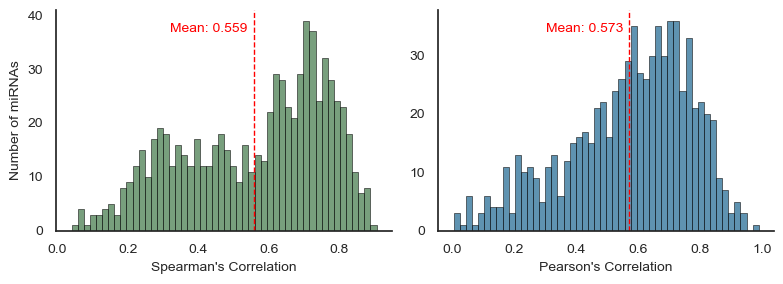

In [18]:
corr_data = calculate_corr(X_test, y_test, axis=0)
print(f"Mean Pearson: {corr_data['pearson'].mean():.4f}  Mean Spearman: {corr_data['spearman'].mean():.4f}")
plot_average_correlation(corr_data, savedir=savedir, filename='Figure 3a - TCGA test prediction correlation.svg')


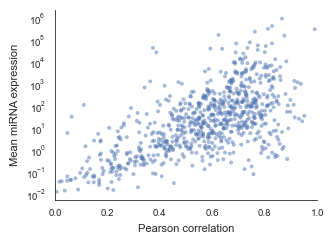

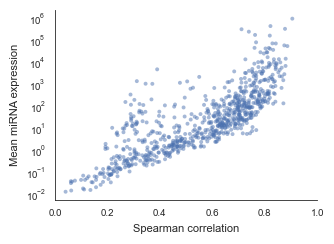

,pearson,spearman,r2,pearson_p,spearman_p,r2_p,mirna,mean_expression
0,0.990359,0.711326,0.980811,0.000000,1.967073e-186,0.000000,hsa-miR-9-5p,314476.218750
1,0.950604,0.396842,0.903648,0.000000,9.921228e-47,0.000000,hsa-miR-520f-3p,35.772614
2,0.942469,0.334177,0.888249,0.000000,7.962791e-33,0.000000,hsa-miR-520c-3p,20.327801
3,0.937586,0.371384,0.879067,0.000000,1.046363e-40,0.000000,hsa-miR-211-5p,1024.920288
4,0.930176,0.291400,0.865229,0.000000,5.161394e-25,0.000000,hsa-miR-302d-3p,26.378424
...,...,...,...,...,...,...,...,...
750,0.046343,0.076263,0.002148,0.107860,8.086129e-03,0.107860,hsa-miR-4731-5p,0.039834
751,0.037420,0.062133,0.001400,0.194267,3.102996e-02,0.194267,hsa-miR-651-3p,0.014108
752,0.026006,0.060768,0.000676,0.367074,3.492756e-02,0.367074,hsa-miR-2467-5p,0.037344
753,0.017674,0.065211,0.000312,0.539915,2.359015e-02,0.539916,hsa-miR-3136-3p,0.035685


In [19]:
# Supplementary Figure 2cd — correlation vs mean expression
plot_corr_vs_mean_expression_pub(
    y_test, corr_data, corr_type="pearson",
    savedir=savedir,
    filename="Supplementary Figure 2c - TCGA Pearson correlation vs mean expression.svg",
)
plot_corr_vs_mean_expression_pub(
    y_test, corr_data, corr_type="spearman",
    savedir=savedir,
    filename="Supplementary Figure 2d - TCGA Spearman correlation vs mean expression.svg",
)

### Save Predictions

In [20]:
outdir = repo_root / "predictions" / "TCGA"
os.makedirs(outdir, exist_ok=True)
X_test.iloc[:, :-4].to_csv(outdir / "TCGA_pred_on_1.tsv", sep="\t")
print("Saved TCGA predictions to", outdir)


Saved TCGA predictions to /Users/au726678/miDGD_paper/predictions/TCGA


In [21]:
# Save GTEx test predictions using the pre-stored gtex_rep from model 1
df_gtex_mrna  = pd.read_table(repo_root / "data" / "GTEx" / "miDGD" / "gtex_mrna.tsv",  sep="\t", index_col=0)
df_gtex_mirna = pd.read_table(repo_root / "data" / "GTEx" / "miDGD" / "gtex_mirna.tsv", sep="\t", index_col=0)
anno_gtex_test = pd.read_table(repo_root / "data" / "GTEx" / "miDGD" / "GTEx_test_anno.tsv", sep="\t", index_col=0)
anno_gtex_test['batch'] = 'GTEx'
from data_functions import replace_tissue_anno
anno_gtex_test = replace_tissue_anno(anno_gtex_test)

gtex_test_mrna  = df_gtex_mrna.loc[anno_gtex_test.index]
gtex_test_mirna = df_gtex_mirna.loc[anno_gtex_test.index].reindex(columns=mirna_column, fill_value=0)

gtex_test_dataset = GeneExpressionDatasetCombined(gtex_test_mrna, gtex_test_mirna, anno_gtex_test, scaling_type=scaling_type)
gtex_test_loader  = torch.utils.data.DataLoader(gtex_test_dataset, batch_size=batch_size,
                                                shuffle=False, num_workers=num_workers, pin_memory=True)

X_gtex, y_gtex = _get_data_pred_from_rep(dgd, dgd.gtex_rep, gtex_test_loader, mirna_column)

outdir_gtex = repo_root / "predictions" / "GTEx"
os.makedirs(outdir_gtex, exist_ok=True)
X_gtex.iloc[:, :-4].to_csv(outdir_gtex / "GTEx_pred_on_1.tsv", sep="\t")
print("Saved GTEx predictions from model 1.")

Saved GTEx predictions from model 1.


### Figure 3 — miRNA Expression Plots

In [22]:
# Get mRNA predictions alongside miRNA predictions for the test set
# mirna_column is already defined above (755 features); train_mrna.columns = 18393 mRNA features
X_mirna_test, y_mirna_test, X_mrna_test, y_mrna_test = _get_data_pred_from_rep_with_mrna(
    dgd, dgd.test_rep, test_loader,
    mirna_column_name=mirna_column,
    mrna_column_name=train_mrna.columns,
)
X_mirna_test.index = anno_test.index
X_mrna_test.index  = anno_test.index

# Pseudo-TPM normalisation for regression plots
def pseudo_tpm(df):
    numeric = df.iloc[:, :-4]
    meta    = df.iloc[:, -4:]
    normed  = numeric.divide(numeric.sum(axis=1), axis=0) * 1e6
    return pd.concat([normed, meta], axis=1)

X_mirna_tpm = pseudo_tpm(X_mirna_test)
X_mrna_tpm  = pseudo_tpm(X_mrna_test)

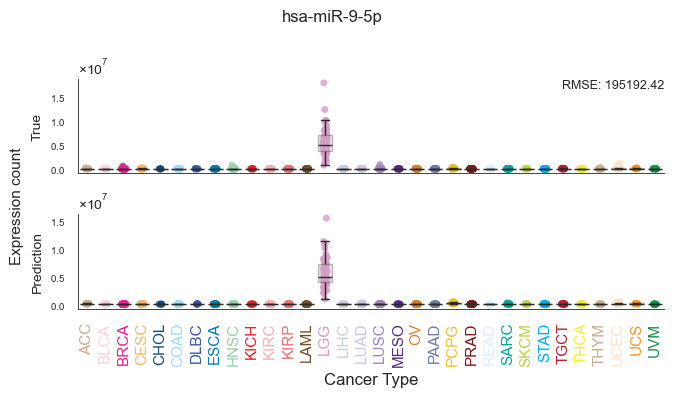

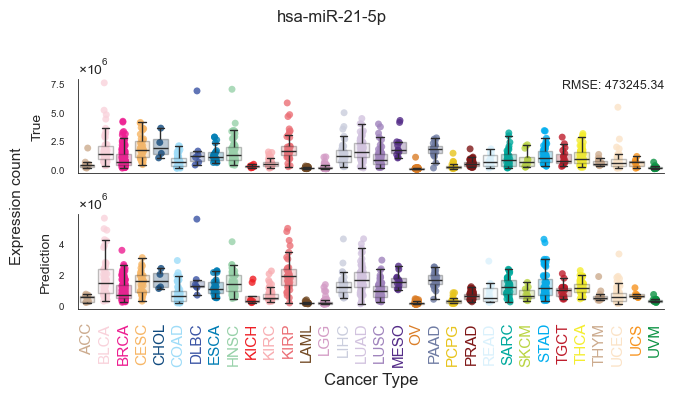

In [23]:
# Figure 3c — True vs predicted expression of miR-9-5p across cancer types
plot_jitter_grouped_tissue(
    X_test, y_test, "hsa-miR-9-5p",
    savedir=savedir,
    filename="Figure 3c - miR-9-5p expression across cancer types.svg",
)

# Figure 3d — True vs predicted expression of miR-21-5p across cancer types
plot_jitter_grouped_tissue(
    X_test, y_test, "hsa-miR-21-5p",
    savedir=savedir,
    filename="Figure 3d - miR-21-5p expression across cancer types.svg",
)

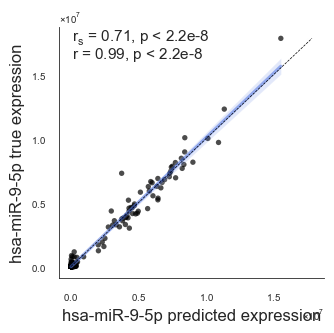

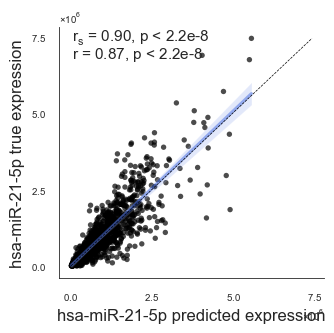

In [24]:
# Figure 3i — True vs predicted regression for miR-9-5p and miR-21-5p
regression_plot(
    X_test, y_test, "hsa-miR-9-5p",
    savedir=savedir,
    filename="Figure 3i - miR-9-5p true vs predicted.svg",
)
regression_plot(
    X_test, y_test, "hsa-miR-21-5p",
    savedir=savedir,
    filename="Figure 3i - miR-21-5p true vs predicted.svg",
)

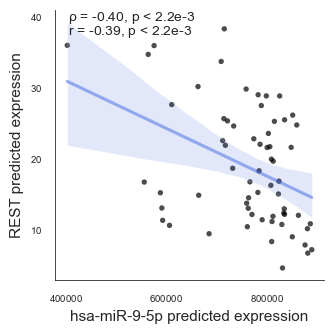

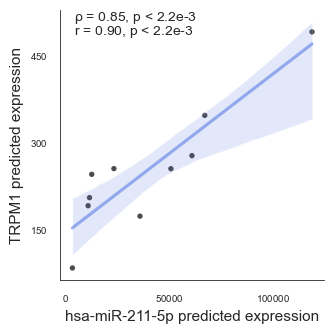

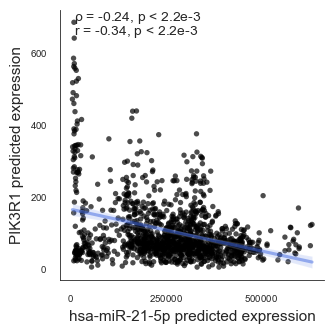

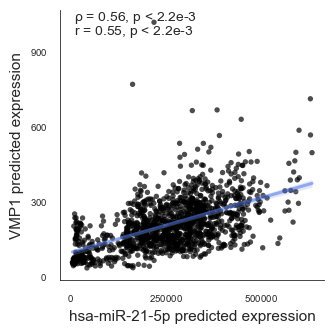

In [25]:
# Figure 3e — predicted miR-9-5p vs predicted REST (ENSG00000084093) in LGG
mirna_vs_mrna_regression(
    X_mirna_tpm, X_mrna_tpm,
    mir="hsa-miR-9-5p", mrna_gene="ENSG00000084093",
    cancer_type="LGG", anno=anno_test,
    ylabel="REST",
    savedir=savedir,
    filename="Figure 3e - miR-9-5p vs REST (LGG).svg",
)

# Figure 3f — predicted miR-211-5p vs predicted TRPM1 (ENSG00000134160) in UVM
mirna_vs_mrna_regression(
    X_mirna_tpm, X_mrna_tpm,
    mir="hsa-miR-211-5p", mrna_gene="ENSG00000134160",
    cancer_type="UVM", anno=anno_test,
    ylabel="TRPM1",
    savedir=savedir,
    filename="Figure 3f - miR-211-5p vs TRPM1 (UVM).svg",
)

# Figure 3g — predicted miR-21-5p vs predicted PIK3R1 (ENSG00000145675) pan-cancer
mirna_vs_mrna_regression(
    X_mirna_tpm, X_mrna_tpm,
    mir="hsa-miR-21-5p", mrna_gene="ENSG00000145675",
    ylabel="PIK3R1",
    savedir=savedir,
    filename="Figure 3g - miR-21-5p vs PIK3R1 (pan-cancer).svg",
)

# Figure 3h — predicted miR-21-5p vs predicted VMP1 (ENSG00000062716) pan-cancer
mirna_vs_mrna_regression(
    X_mirna_tpm, X_mrna_tpm,
    mir="hsa-miR-21-5p", mrna_gene="ENSG00000062716",
    ylabel="VMP1",
    savedir=savedir,
    filename="Figure 3h - miR-21-5p vs VMP1 (pan-cancer).svg",
)